In [12]:
!pip install ucimlrepo -q

from ucimlrepo import fetch_ucirepo
import pandas as pd

# تحميل الداتاسيت الرسمي من UCI (Phishing Websites, ID=327)
phishing = fetch_ucirepo(id=327)

X = phishing.data.features   # الخصائص (30 عمود)
y = phishing.data.targets    # التصنيف (phishing أو لا)

# دمجهم في جدول واحد للتسهيل
df = pd.concat([X, y], axis=1)

print("عدد الصفوف والأعمدة:", df.shape)
df.head()

عدد الصفوف والأعمدة: (11055, 31)


,having_ip_address,url_length,shortining_service,having_at_symbol,double_slash_redirecting,prefix_suffix,having_sub_domain,sslfinal_state,domain_registration_length,favicon,...,popupwindow,iframe,age_of_domain,dnsrecord,web_traffic,page_rank,google_index,links_pointing_to_page,statistical_report,result
0,-1,1,1,1,-1,-1,-1,-1,-1,1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,1,1,1,1,1,-1,0,1,-1,1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,1,0,1,1,1,-1,-1,-1,-1,1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,1,0,-1,1,1,-1,1,1,-1,1,...,-1,1,-1,-1,0,-1,1,1,1,1


In [13]:
# فحص القيم الناقصة
print("القيم الناقصة في كل عمود:")
print(df.isnull().sum().sum())

# فحص توزيع التصنيف (كم موقع phishing وكم legitimate)
print("\nتوزيع التصنيف:")
print(df['result'].value_counts())

# أسماء الأعمدة كاملة
print("\nأسماء الأعمدة:")
print(df.columns.tolist())

القيم الناقصة في كل عمود:
0

توزيع التصنيف:
result
 1    6157
-1    4898
Name: count, dtype: int64

أسماء الأعمدة:
['having_ip_address', 'url_length', 'shortining_service', 'having_at_symbol', 'double_slash_redirecting', 'prefix_suffix', 'having_sub_domain', 'sslfinal_state', 'domain_registration_length', 'favicon', 'port', 'https_token', 'request_url', 'url_of_anchor', 'links_in_tags', 'sfh', 'submitting_to_email', 'abnormal_url', 'redirect', 'on_mouseover', 'rightclick', 'popupwindow', 'iframe', 'age_of_domain', 'dnsrecord', 'web_traffic', 'page_rank', 'google_index', 'links_pointing_to_page', 'statistical_report', 'result']


In [14]:
from sklearn.model_selection import train_test_split

# فصل الخصائص (X) عن الهدف (y)
X = df.drop('result', axis=1)
y = df['result']

# تقسيم البيانات: 80% تدريب، 20% اختبار
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("حجم بيانات التدريب:", X_train.shape)
print("حجم بيانات الاختبار:", X_test.shape)

حجم بيانات التدريب: (8844, 30)
حجم بيانات الاختبار: (2211, 30)


In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# إنشاء النموذج وتدريبه
model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train, y_train)

# التنبؤ على بيانات الاختبار
y_pred_lr = model_lr.predict(X_test)

# قياس الدقة
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print("دقة نموذج Logistic Regression:", round(accuracy_lr * 100, 2), "%")

print("\nتقرير مفصل:")
print(classification_report(y_test, y_pred_lr))

دقة نموذج Logistic Regression: 92.45 %

تقرير مفصل:
              precision    recall  f1-score   support

          -1       0.92      0.90      0.91       956
           1       0.93      0.94      0.93      1255

    accuracy                           0.92      2211
   macro avg       0.92      0.92      0.92      2211
weighted avg       0.92      0.92      0.92      2211



In [16]:
from sklearn.ensemble import RandomForestClassifier

# إنشاء النموذج وتدريبه
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

# التنبؤ
y_pred_rf = model_rf.predict(X_test)

# قياس الدقة
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("دقة نموذج Random Forest:", round(accuracy_rf * 100, 2), "%")

print("\nتقرير مفصل:")
print(classification_report(y_test, y_pred_rf))

دقة نموذج Random Forest: 96.7 %

تقرير مفصل:
              precision    recall  f1-score   support

          -1       0.97      0.95      0.96       956
           1       0.96      0.98      0.97      1255

    accuracy                           0.97      2211
   macro avg       0.97      0.97      0.97      2211
weighted avg       0.97      0.97      0.97      2211



In [17]:
from sklearn.svm import SVC

# إنشاء النموذج وتدريبه
model_svm = SVC(kernel='rbf', random_state=42)
model_svm.fit(X_train, y_train)

# التنبؤ
y_pred_svm = model_svm.predict(X_test)

# قياس الدقة
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print("دقة نموذج SVM:", round(accuracy_svm * 100, 2), "%")

print("\nتقرير مفصل:")
print(classification_report(y_test, y_pred_svm))

دقة نموذج SVM: 94.71 %

تقرير مفصل:
              precision    recall  f1-score   support

          -1       0.95      0.92      0.94       956
           1       0.94      0.97      0.95      1255

    accuracy                           0.95      2211
   macro avg       0.95      0.94      0.95      2211
weighted avg       0.95      0.95      0.95      2211



                 Model  Accuracy (%)
0  Logistic Regression         92.45
1        Random Forest         96.70
2                  SVM         94.71


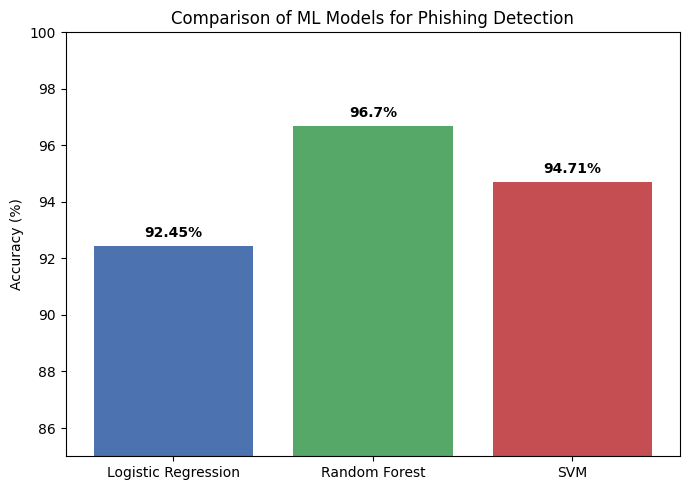

In [18]:
import matplotlib.pyplot as plt

# جدول المقارنة
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'SVM'],
    'Accuracy': [accuracy_lr, accuracy_rf, accuracy_svm]
})
results['Accuracy (%)'] = (results['Accuracy'] * 100).round(2)
print(results[['Model', 'Accuracy (%)']])

# رسم بياني
plt.figure(figsize=(7,5))
plt.bar(results['Model'], results['Accuracy (%)'], color=['#4c72b0', '#55a868', '#c44e52'])
plt.ylim(85, 100)
plt.ylabel('Accuracy (%)')
plt.title('Comparison of ML Models for Phishing Detection')
for i, v in enumerate(results['Accuracy (%)']):
    plt.text(i, v + 0.3, str(v)+'%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300)
plt.show()

Logistic Regression: متوسط الدقة عبر 5 مجموعات = 92.28% (± 0.48%)
Random Forest: متوسط الدقة عبر 5 مجموعات = 96.84% (± 1.51%)
SVM: متوسط الدقة عبر 5 مجموعات = 94.46% (± 0.66%)


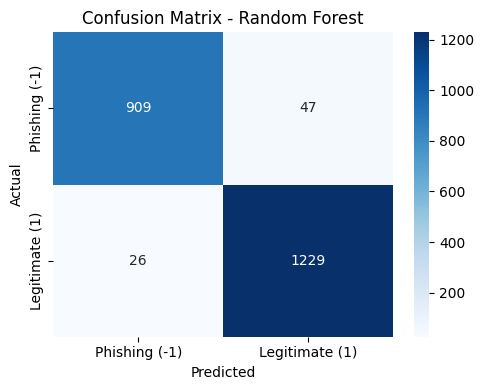

In [19]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix
import seaborn as sns

# 1) Cross-Validation (5-fold) للنماذج الثلاثة
for name, model in [('Logistic Regression', model_lr), ('Random Forest', model_rf), ('SVM', model_svm)]:
    scores = cross_val_score(model, X, y, cv=5)
    print(f"{name}: متوسط الدقة عبر 5 مجموعات = {scores.mean()*100:.2f}% (± {scores.std()*100:.2f}%)")

# 2) Confusion Matrix لأفضل نموذج (Random Forest)
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Phishing (-1)', 'Legitimate (1)'],
            yticklabels=['Phishing (-1)', 'Legitimate (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()